In [44]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

# GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Path to tiles
folder_path = "/home/jiit_9923103250/minor_wGhats_tiles-20260424T061409Z-3-001/minor_wGhats_tiles"
tile_paths = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.tif')]
print(f"Found {len(tile_paths)} tiles")

Found 58 tiles


In [45]:
def load_tile_safe(path):
    """Load tile, skip mostly NaN tiles, normalize, binary label"""
    try:
        with rasterio.open(path) as src:
            data = src.read()
    except:
        return None, None, None

    # skip mostly NaN tiles
    if np.isnan(data).mean() > 0.9:
        return None, None, None

    t1 = data[:6] 
    t1 = (t1 - np.mean(t1)) / (np.std(t1) + 1e-6) # normalize
    t2 = data[6:12] / 10000.0
    label = (data[12] > 0).astype(np.float32)

    t1 = np.nan_to_num(t1, nan=0.0)
    t2 = np.nan_to_num(t2, nan=0.0)
    label = np.nan_to_num(label, nan=0.0)

    return t1, t2, label

In [46]:
def create_patches(t1, t2, label, size=128):
    patches = []
    _, H, W = t1.shape
    for i in range(0, H - size + 1, size):
        for j in range(0, W - size + 1, size):
            p1 = t1[:, i:i+size, j:j+size]
            p2 = t2[:, i:i+size, j:j+size]
            pl = label[i:i+size, j:j+size]

            # Skip empty/black patches
            if np.mean(p1) < 0.001 and np.mean(p2) < 0.01:
                continue

            # Oversample positive patches
            if np.sum(pl) == 0:
                if np.random.rand() > 0.3:  # keep 30% negatives
                    continue

            patches.append((p1, p2, pl))
    return patches

In [47]:
class DeforestationDataset(Dataset):
    def __init__(self, tile_paths):
        self.samples = []

        for path in tile_paths:
            t1, t2, label = load_tile_safe(path)
            if t1 is None:
                continue

            patches = create_patches(t1, t2, label)
            self.samples.extend(patches)

        print("Total valid patches:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        t1, t2, label = self.samples[idx]
        x = np.concatenate([t1, t2], axis=0)
        return torch.tensor(x, dtype=torch.float32), torch.tensor(label, dtype=torch.float32).unsqueeze(0)

In [48]:
dataset = DeforestationDataset(tile_paths)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

Total valid patches: 2203


In [49]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, ratio=8):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // ratio, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // ratio, in_channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg = torch.mean(x, dim=1, keepdim=True)
        mx, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg, mx], dim=1)
        return self.sigmoid(self.conv(x))

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.ca = ChannelAttention(channels)
        self.sa = SpatialAttention()
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

In [50]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        )
    def forward(self, x):
        return self.conv(x)

class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = ConvBlock(6, 32)
        self.enc2 = ConvBlock(32, 64)
        self.enc3 = ConvBlock(64, 128)
        self.pool = nn.MaxPool2d(2)
    def forward(self, x):
        f1 = self.enc1(x)
        f2 = self.enc2(self.pool(f1))
        f3 = self.enc3(self.pool(f2))
        return f1, f2, f3

class FPN(nn.Module):
    def __init__(self):
        super().__init__()
        self.lat3 = nn.Conv2d(128, 64, 1)
        self.lat2 = nn.Conv2d(64, 64, 1)
        self.lat1 = nn.Conv2d(32, 64, 1)
    def forward(self, f1, f2, f3):
        p3 = self.lat3(f3)
        p2 = self.lat2(f2) + F.interpolate(p3, scale_factor=2, mode='nearest')
        p1 = self.lat1(f1) + F.interpolate(p2, scale_factor=2, mode='nearest')
        return p1

class SiameseFPN_CBAM(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.fpn = FPN()
        self.cbam = CBAM(64)
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 1, 1)
        )
    def forward(self, x):
        t1 = x[:, :6]
        t2 = x[:, 6:]
        t1_f1, t1_f2, t1_f3 = self.encoder(t1)
        t2_f1, t2_f2, t2_f3 = self.encoder(t2)
        d1 = torch.abs(t2_f1 - t1_f1)
        d2 = torch.abs(t2_f2 - t1_f2)
        d3 = torch.abs(t2_f3 - t1_f3)
        x = self.fpn(d1, d2, d3)
        x = self.cbam(x)
        return self.decoder(x)

In [51]:
def dice_loss(pred, target, smooth=1):
    pred = torch.sigmoid(pred)
    pred = pred.view(-1)
    target = target.view(-1)
    inter = (pred * target).sum()
    return 1 - ((2. * inter + smooth) / (pred.sum() + target.sum() + smooth))

# Class balancing
pos = 0.0
neg = 0.0
for _, y in loader:
    pos += (y==1).sum().item()
    neg += (y==0).sum().item()
pos_weight = torch.tensor(min(neg/pos,10)).to(device)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
def focal_loss(inputs, targets, alpha=0.25, gamma=2):
    """
    inputs: predicted logits (before sigmoid)
    targets: ground truth labels (0 or 1)
    """
    inputs = inputs.sigmoid()  # if your model outputs logits
    targets = targets.type_as(inputs)
    BCE = F.binary_cross_entropy(inputs, targets, reduction='none')
    pt = torch.where(targets == 1, inputs, 1 - inputs)
    loss = BCE * ((1 - pt) ** gamma)
    if alpha is not None:
        alpha_t = torch.where(targets == 1, alpha, 1 - alpha)
        loss = alpha_t * loss
    return loss.mean()

In [52]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        return (self.alpha * (1 - pt) ** self.gamma * bce).mean()


In [53]:
model = SiameseFPN_CBAM().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 30

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        pred = model(x)
        loss = focal_loss(pred, y) + dice_loss(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")

Epoch 1/30, Loss: 245.3804
Epoch 2/30, Loss: 232.7481
Epoch 3/30, Loss: 228.8473
Epoch 4/30, Loss: 227.5288
Epoch 5/30, Loss: 224.4046
Epoch 6/30, Loss: 222.2776
Epoch 7/30, Loss: 223.1211
Epoch 8/30, Loss: 222.8262
Epoch 9/30, Loss: 222.5298
Epoch 10/30, Loss: 219.9338
Epoch 11/30, Loss: 220.6676
Epoch 12/30, Loss: 221.0916
Epoch 13/30, Loss: 217.2301
Epoch 14/30, Loss: 218.0325
Epoch 15/30, Loss: 217.6768
Epoch 16/30, Loss: 216.8755
Epoch 17/30, Loss: 218.3703
Epoch 18/30, Loss: 214.4981
Epoch 19/30, Loss: 215.4218
Epoch 20/30, Loss: 213.7783
Epoch 21/30, Loss: 215.0059
Epoch 22/30, Loss: 215.7403
Epoch 23/30, Loss: 212.8932
Epoch 24/30, Loss: 216.1798
Epoch 25/30, Loss: 210.3365
Epoch 26/30, Loss: 211.3167
Epoch 27/30, Loss: 210.7610
Epoch 28/30, Loss: 210.3824
Epoch 29/30, Loss: 211.4120
Epoch 30/30, Loss: 210.7849


In [54]:

torch.save(model.state_dict(), "model_final4.pth")
print("Model saved as model_final4.pth")

Model saved as model_final4.pth


PR AUC: 0.0383


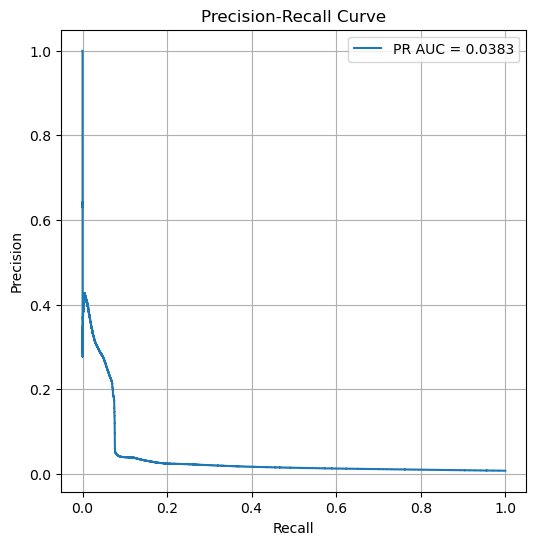


Best Threshold: 0.2193
Best F1 from curve: 0.1057

===== FINAL METRICS (Best Threshold) =====
Confusion Matrix:
 [[35751273    70543]
 [  253007    19129]]
Accuracy : 0.9910
Precision: 0.2133
Recall   : 0.0703
F1 Score : 0.1057
IoU      : 0.0558

Predicted positives %: 0.0024844051435542443
Actual positives %: 0.007539656505333636


In [55]:

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        prob = torch.sigmoid(model(x))  
        all_probs.append(prob.cpu().numpy().flatten())
        all_labels.append(y.cpu().numpy().flatten())

all_probs = np.concatenate(all_probs)
all_labels = np.concatenate(all_labels)

mask = ~np.isnan(all_labels)
all_probs = all_probs[mask]
all_labels = all_labels[mask]

all_labels = (all_labels > 0.5).astype(int)

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
pr_auc = auc(recall, precision)

print(f"PR AUC: {pr_auc:.4f}")

# ---- Plot PR Curve ----
plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\nBest Threshold: {best_threshold:.4f}")
print(f"Best F1 from curve: {f1_scores[best_idx]:.4f}")

all_preds = (all_probs > best_threshold).astype(int)

cm = confusion_matrix(all_labels, all_preds)

if cm.shape == (2,2):
    tn, fp, fn, tp = cm.ravel()
else:
    tn = fp = fn = tp = 0

accuracy  = (tp + tn) / (tp + tn + fp + fn + 1e-6)
precision_val = precision_score(all_labels, all_preds, zero_division=0)
recall_val    = recall_score(all_labels, all_preds, zero_division=0)
f1_val        = f1_score(all_labels, all_preds, zero_division=0)
iou           = tp / (tp + fp + fn + 1e-6)

print("\n===== FINAL METRICS (Best Threshold) =====")
print("Confusion Matrix:\n", cm)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision_val:.4f}")
print(f"Recall   : {recall_val:.4f}")
print(f"F1 Score : {f1_val:.4f}")
print(f"IoU      : {iou:.4f}")

print("\nPredicted positives %:", all_preds.mean())
print("Actual positives %:", all_labels.mean())

In [56]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = torch.sigmoid(model(x))
        pred = (pred > best_threshold).float()
        all_preds.append(pred.cpu().numpy().flatten())
        all_labels.append(y.cpu().numpy().flatten())

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

mask = ~np.isnan(all_labels)
all_preds = (all_preds[mask] > best_threshold).astype(int)
all_labels = (all_labels[mask] > best_threshold).astype(int)

cm = confusion_matrix(all_labels, all_preds)
if cm.shape == (2,2):
    tn, fp, fn, tp = cm.ravel()
else:
    tn = fp = fn = tp = 0

accuracy  = (tp + tn) / (tp + tn + fp + fn + 1e-6)
precision = precision_score(all_labels, all_preds, zero_division=0)
recall    = recall_score(all_labels, all_preds, zero_division=0)
f1        = f1_score(all_labels, all_preds, zero_division=0)
iou       = tp / (tp + fp + fn + 1e-6)

print("Confusion Matrix:\n", cm)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"IoU      : {iou:.4f}")

Confusion Matrix:
 [[35751273    70543]
 [  253007    19129]]
Accuracy : 0.9910
Precision: 0.2133
Recall   : 0.0703
F1 Score : 0.1057
IoU      : 0.0558


PR AUC: 0.0073


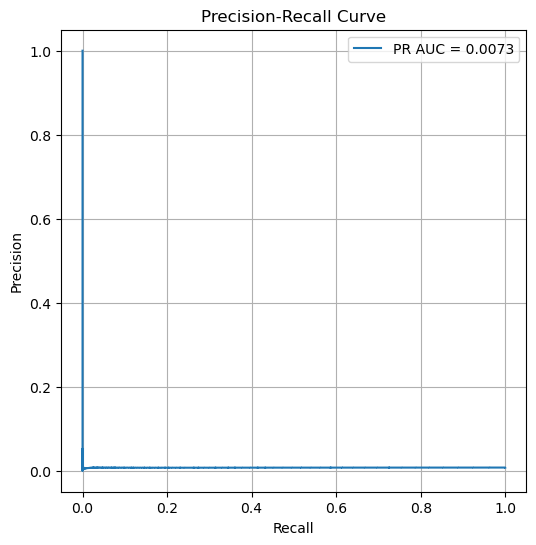

Best Threshold: 0.0000
Best F1 from curve: 0.0150


In [57]:
from sklearn.metrics import precision_recall_curve, auc

# Use RAW probabilities (important!)
probs = all_probs
labels = all_labels

precision, recall, thresholds = precision_recall_curve(labels, probs)
pr_auc = auc(recall, precision)

print(f"PR AUC: {pr_auc:.4f}")

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(recall, precision, label=f"PR AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 from curve: {f1_scores[best_idx]:.4f}")

In [58]:
print("Predicted positives %:", all_preds.mean())
print("Actual positives %:", all_labels.mean())

Predicted positives %: 0.0024844051435542443
Actual positives %: 0.007539656505333636


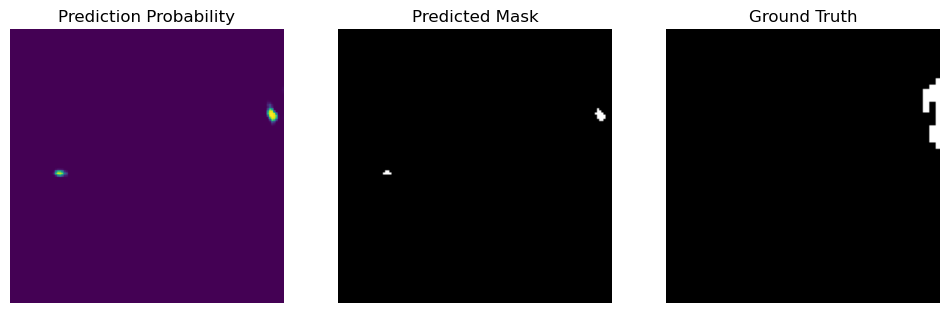

In [59]:
import matplotlib.pyplot as plt

# pick a sample
x, y = dataset[0]  # first patch
x = x.unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    pred = torch.sigmoid(model(x))

# convert to CPU and numpy
pred_prob = pred.squeeze().cpu().numpy()
binary_mask = (pred_prob > 0.6).astype(float)
y_np = y.squeeze().numpy()

plt.figure(figsize=(12,4))

# Prediction probabilities
plt.subplot(1,3,1)
plt.imshow(pred_prob, cmap='viridis')
plt.title("Prediction Probability")
plt.axis('off')

# Binary mask
plt.subplot(1,3,2)
plt.imshow(binary_mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

# Ground truth
plt.subplot(1,3,3)
plt.imshow(y_np, cmap='gray')
plt.title("Ground Truth")
plt.axis('off')

plt.show()

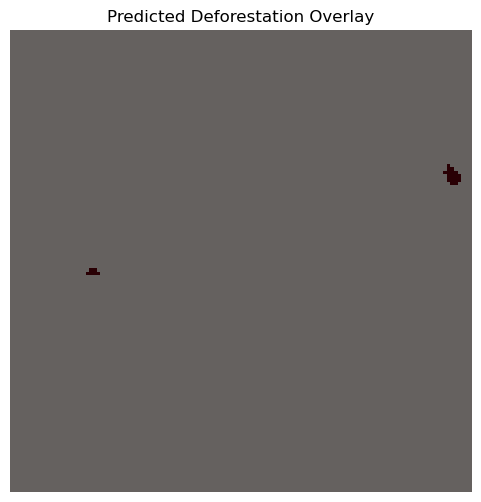

In [60]:
# Split T1 and T2 from input
t1 = x[0, :6].cpu().numpy()
t2 = x[0, 6:].cpu().numpy()

# Create RGB from T1
rgb = t1[[2,1,0]].transpose(1,2,0)  # B4,B3,B2
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

plt.figure(figsize=(6,6))
plt.imshow(rgb)

# Overlay predicted mask in red
plt.imshow(binary_mask, cmap='Reds', alpha=0.4)
plt.title("Predicted Deforestation Overlay")
plt.axis('off')
plt.show()

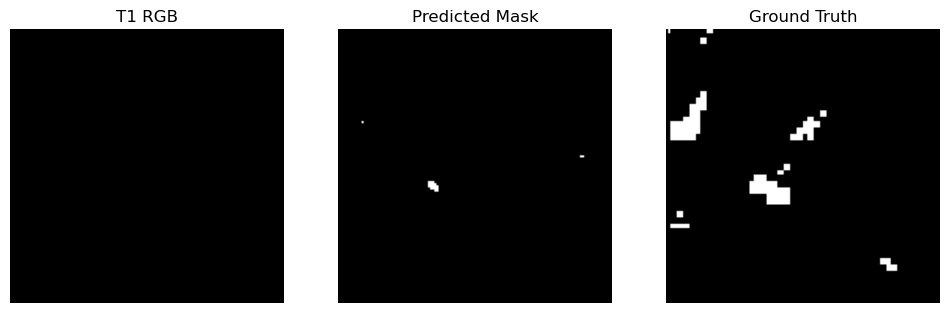

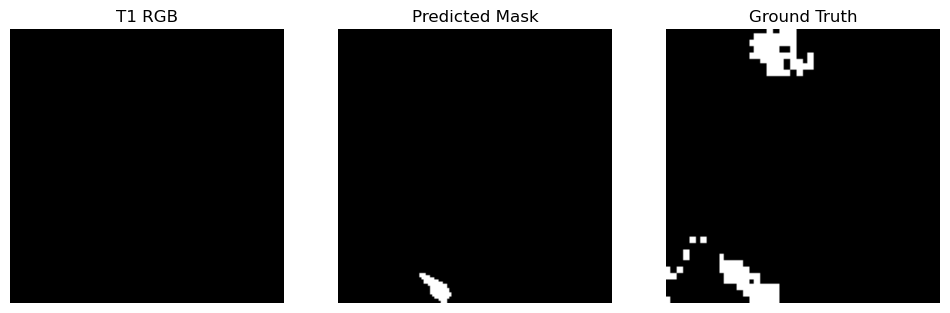

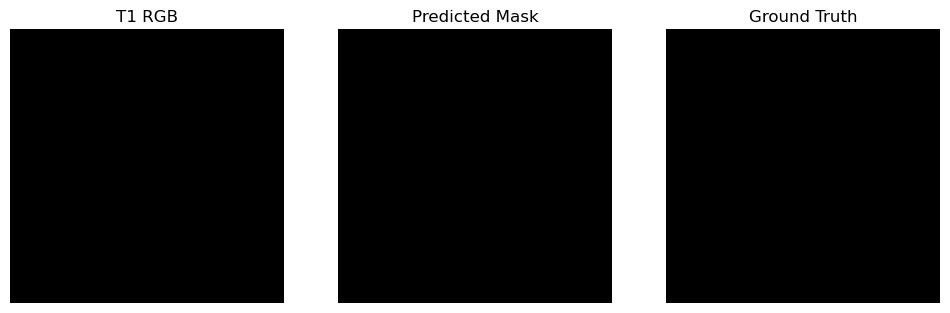

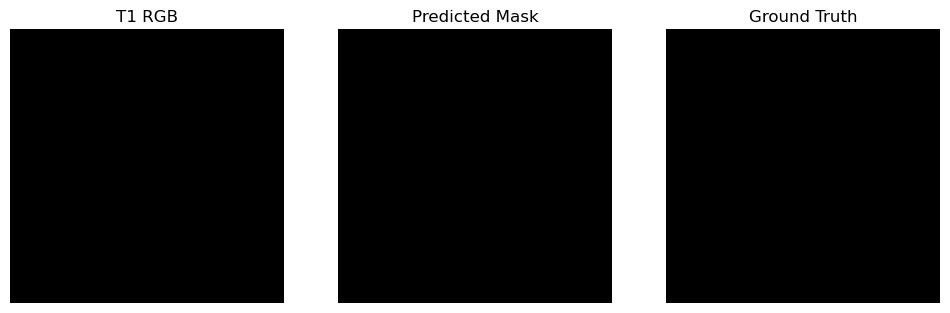

In [61]:
# Visualize a few patches from loader
batch = next(iter(loader))
x_batch, y_batch = batch
x_batch = x_batch.to(device)

with torch.no_grad():
    preds = torch.sigmoid(model(x_batch))
    preds_binary = (preds > 0.6).float()

for i in range(min(4, x_batch.size(0))):
    t1 = x_batch[i, :6].cpu().numpy()
    y_np = y_batch[i,0].numpy()
    pred_mask = preds_binary[i,0].cpu().numpy()

    rgb = t1[[2,1,0]].transpose(1,2,0)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(rgb)
    plt.title("T1 RGB")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(y_np, cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')

    plt.show()

In [62]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(all_labels, all_preds)
print(f"Balanced Accuracy: {balanced_acc:.4f}")
# per-class accuracy
acc_pos = tp / (tp + fn + 1e-6)
acc_neg = tn / (tn + fp + 1e-6)

print(f"Positive class accuracy (recall): {acc_pos:.4f}")
print(f"Negative class accuracy: {acc_neg:.4f}")
balanced_acc = (acc_pos + acc_neg) / 2

Balanced Accuracy: 0.5342
Positive class accuracy (recall): 0.0703
Negative class accuracy: 0.9980
